# 02. 가설 검정

01 EDA에서 눈으로 본 패턴들을 통계 검정으로 확인한다.

- H1. EXT_SOURCE_2 평균이 부도군과 정상군에서 다른가 (t-test)
- H2. 연령대별 부도율 차이 (chi-square)
- H3. 직업과 부도 (chi-square)
- H4. 교육수준과 부도 (chi-square)
- H5. EXT_SOURCE_1 결측 여부가 부도와 관련 있는가 (chi-square)
- H6. 소득 평균 차이 (t-test, Mann-Whitney)

표본이 30만개라 p값은 거의 다 유의하게 나온다. 그래서 p값보다 effect size(Cohen's d, Cramer's V)로 차이의 크기를 본다.

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')

# 한글 폰트: 설치된 것 중 있는 걸로 잡는다 (seaborn 설정 뒤에 적용해야 안 덮인다)
installed = {f.name for f in fm.fontManager.ttflist}
for name in ['Malgun Gothic', 'NanumGothic', 'NanumBarunGothic', 'Gulim', 'Batang']:
    if name in installed:
        plt.rcParams['font.family'] = name
        print('한글 폰트:', name)
        break
else:
    print('한글 폰트 못 찾음. 그래프 한글 깨질 수 있음')

plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', 200)

한글 폰트: Malgun Gothic


In [4]:
df = pd.read_csv('../data/raw/application_train.csv')

df['AGE_YEARS'] = -df['DAYS_BIRTH'] / 365.25
df['AGE_BUCKET'] = pd.cut(df['AGE_YEARS'], bins=[20, 30, 40, 50, 60, 70])
df['EXT1_MISSING'] = df['EXT_SOURCE_1'].isnull().astype(int)

base_rate = df['TARGET'].mean()
print('shape:', df.shape)
print(f'전체 부도율: {base_rate*100:.2f}%')

shape: (307511, 125)
전체 부도율: 8.07%


effect size 함수. 표본이 크면 p값은 의미가 없어지니까 차이 크기를 표준화해서 같이 본다.

In [5]:
def cohens_d(x, y):
    nx, ny = len(x), len(y)
    pooled = np.sqrt(((nx-1)*x.std()**2 + (ny-1)*y.std()**2) / (nx+ny-2))
    return (x.mean() - y.mean()) / pooled

def cramers_v(ct):
    chi2 = stats.chi2_contingency(ct)[0]
    n = ct.sum().sum()
    r, k = ct.shape
    return np.sqrt(chi2 / (n * (min(r, k) - 1)))

## H1. EXT_SOURCE_2

01에서 부도와 상관이 가장 컸던 변수. 부도군/정상군 평균이 실제로 갈리는지 t-test로 본다.
분산이 다를 수 있으니 Welch.

정상군 평균 0.523, 부도군 평균 0.411
t=80.5, p=0.00e+00, Cohen d=0.597


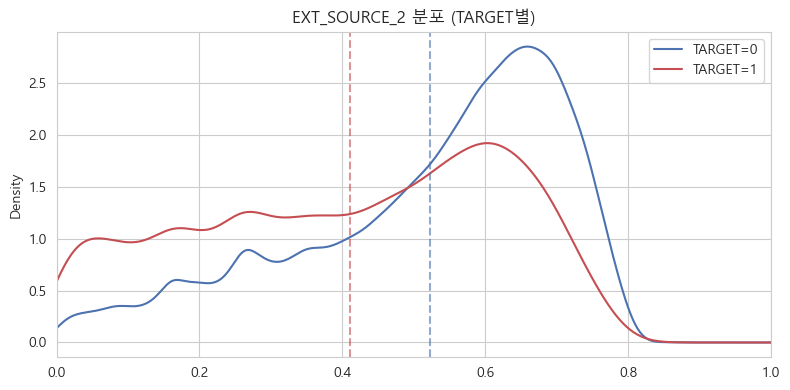

In [6]:
g0 = df.loc[df['TARGET'] == 0, 'EXT_SOURCE_2'].dropna()
g1 = df.loc[df['TARGET'] == 1, 'EXT_SOURCE_2'].dropna()

t_stat, p_val = stats.ttest_ind(g0, g1, equal_var=False)
d = cohens_d(g0, g1)

print(f'정상군 평균 {g0.mean():.3f}, 부도군 평균 {g1.mean():.3f}')
print(f't={t_stat:.1f}, p={p_val:.2e}, Cohen d={d:.3f}')

fig, ax = plt.subplots(figsize=(8, 4))
for t, c in [(0, '#4C72B0'), (1, '#C44E52')]:
    df.loc[df['TARGET'] == t, 'EXT_SOURCE_2'].plot.kde(ax=ax, label=f'TARGET={t}', color=c)
ax.axvline(g0.mean(), color='#4C72B0', ls='--', alpha=.6)
ax.axvline(g1.mean(), color='#C44E52', ls='--', alpha=.6)
ax.set_title('EXT_SOURCE_2 분포 (TARGET별)')
ax.set_xlim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## H2. 연령대

chi2=1789, p=0.00e+00, dof=4, Cramer V=0.076
AGE_BUCKET
(20, 30]    11.44
(30, 40]     9.59
(40, 50]     7.64
(50, 60]     6.12
(60, 70]     4.92
Name: TARGET, dtype: float64


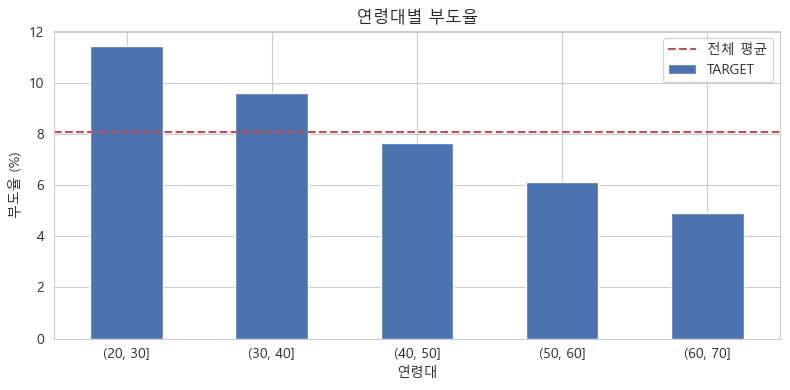

In [7]:
ct_age = pd.crosstab(df['AGE_BUCKET'], df['TARGET'])
chi2_age, p_age, dof_age, _ = stats.chi2_contingency(ct_age)
v_age = cramers_v(ct_age)

age_rate = (df.groupby('AGE_BUCKET')['TARGET'].mean() * 100).round(2)
print(f'chi2={chi2_age:.0f}, p={p_age:.2e}, dof={dof_age}, Cramer V={v_age:.3f}')
print(age_rate)

fig, ax = plt.subplots(figsize=(8, 4))
age_rate.plot(kind='bar', color='#4C72B0', ax=ax)
ax.axhline(base_rate*100, color='#C44E52', ls='--', label='전체 평균')
ax.set_ylabel('부도율 (%)')
ax.set_xlabel('연령대')
ax.set_title('연령대별 부도율')
ax.set_xticklabels([str(x) for x in age_rate.index], rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

## H3, H4. 직업과 교육

직업  chi2=1403, p=3.78e-288, Cramer V=0.082
교육  chi2=1019, p=2.45e-219, Cramer V=0.058


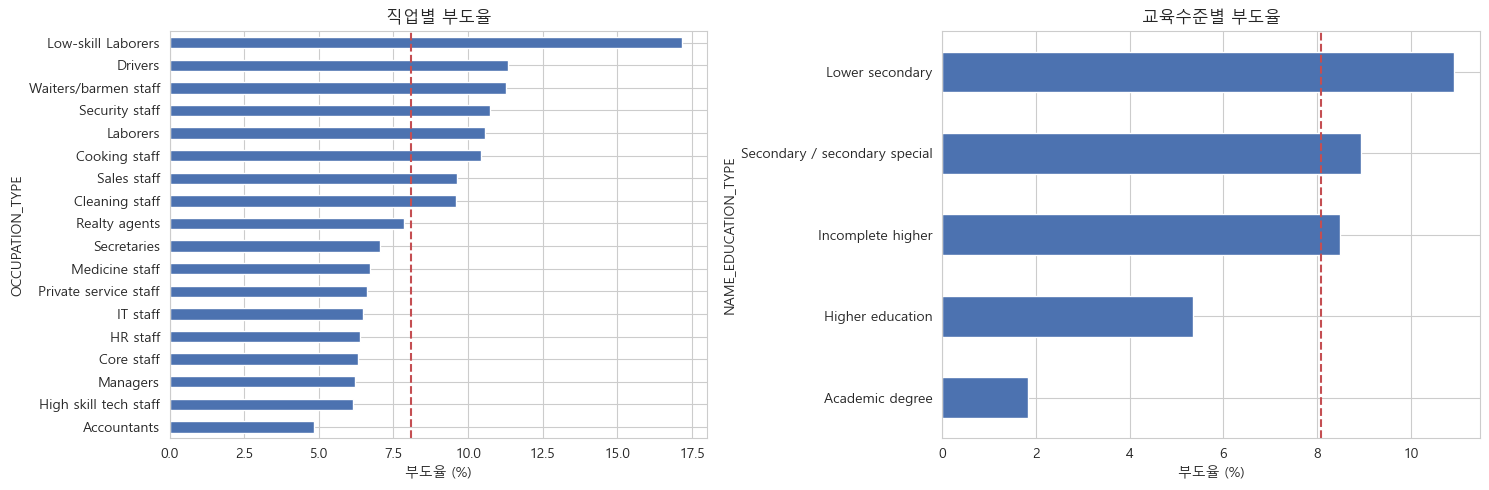

NAME_EDUCATION_TYPE
Secondary / secondary special    0.710
Higher education                 0.243
Incomplete higher                0.033
Lower secondary                  0.012
Academic degree                  0.001
Name: proportion, dtype: float64

In [9]:
ct_occ = pd.crosstab(df['OCCUPATION_TYPE'], df['TARGET'])
chi2_occ, p_occ, _, _ = stats.chi2_contingency(ct_occ)
v_occ = cramers_v(ct_occ)

ct_edu = pd.crosstab(df['NAME_EDUCATION_TYPE'], df['TARGET'])
chi2_edu, p_edu, _, _ = stats.chi2_contingency(ct_edu)
v_edu = cramers_v(ct_edu)

print(f'직업  chi2={chi2_occ:.0f}, p={p_occ:.2e}, Cramer V={v_occ:.3f}')
print(f'교육  chi2={chi2_edu:.0f}, p={p_edu:.2e}, Cramer V={v_edu:.3f}')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
occ_rate = (df.groupby('OCCUPATION_TYPE')['TARGET'].mean()*100).sort_values()
occ_rate.plot(kind='barh', color='#4C72B0', ax=axes[0])
axes[0].axvline(base_rate*100, color='#C44E52', ls='--')
axes[0].set_title('직업별 부도율')
axes[0].set_xlabel('부도율 (%)')

edu_rate = (df.groupby('NAME_EDUCATION_TYPE')['TARGET'].mean()*100).sort_values()
edu_rate.plot(kind='barh', color='#4C72B0', ax=axes[1])
axes[1].axvline(base_rate*100, color='#C44E52', ls='--')
axes[1].set_title('교육수준별 부도율')
axes[1].set_xlabel('부도율 (%)')
plt.tight_layout()
plt.show()
df['NAME_EDUCATION_TYPE'].value_counts(normalize=True).round(3)

## H5. EXT_SOURCE_1 결측

외부 평점이 아예 없는 것 자체가 신호인지 본다. 결측이면 1.

In [ ]:
ct_miss = pd.crosstab(df['EXT1_MISSING'], df['TARGET'])
chi2_miss, p_miss, _, _ = stats.chi2_contingency(ct_miss)
v_miss = cramers_v(ct_miss)

rate_miss = df.loc[df['EXT1_MISSING'] == 1, 'TARGET'].mean() * 100
rate_obs = df.loc[df['EXT1_MISSING'] == 0, 'TARGET'].mean() * 100
print(f'chi2={chi2_miss:.0f}, p={p_miss:.2e}, Cramer V={v_miss:.3f}')
print(f'결측 그룹 {rate_miss:.2f}%, 보유 그룹 {rate_obs:.2f}%, 차이 {rate_miss-rate_obs:+.2f}%p')

fig, ax = plt.subplots(figsize=(5, 4))
pd.Series({'결측': rate_miss, '보유': rate_obs}).plot(kind='bar', color=['#C44E52', '#4C72B0'], ax=ax)
ax.axhline(base_rate*100, color='gray', ls='--', label='전체 평균')
ax.set_ylabel('부도율 (%)')
ax.set_title('EXT_SOURCE_1 결측 여부별 부도율')
ax.set_xticklabels(['결측', '보유'], rotation=0)
ax.legend()
plt.tight_layout()
plt.show()

## H6. 소득

소득은 right-skew가 심해서 상위 1% 자르고, t-test에 Mann-Whitney도 같이 본다.

In [ ]:
cap = df['AMT_INCOME_TOTAL'].quantile(0.99)
i0 = df.loc[df['TARGET'] == 0, 'AMT_INCOME_TOTAL'].clip(upper=cap)
i1 = df.loc[df['TARGET'] == 1, 'AMT_INCOME_TOTAL'].clip(upper=cap)

t_inc, p_inc = stats.ttest_ind(i0, i1, equal_var=False)
u_inc, p_u = stats.mannwhitneyu(i0, i1, alternative='two-sided')
d_inc = cohens_d(i0, i1)

print(f'정상군 평균소득 {i0.mean():,.0f}, 부도군 평균소득 {i1.mean():,.0f}')
print(f't={t_inc:.1f}, p={p_inc:.2e}, Cohen d={d_inc:.3f}')
print(f'Mann-Whitney p={p_u:.2e}')

## 정리

표본이 30만이라 6개 가설 모두 p값은 유의하게 나왔다. p값으로는 변별이 안 되니 effect size로 차이의 크기를 봤다.

effect size 순으로 보면:

- EXT_SOURCE_2: Cohen d 0.597. 유일하게 쓸 만한 단변량 신호다. 외부 신용점수라 내용을 알 수 없는 블랙박스인 점은 감안.
- 직업: Cramer V 0.082. 저숙련·운전·서비스직이 위험.
- 연령: Cramer V 0.076. 20대 11.4%에서 60대 4.9%로 단조 감소.
- 교육: Cramer V 0.058. 학력 높을수록 낮아지지만 대다수가 평균 근처라 전체 연관성은 약함.
- 소득: Cohen d 0.086. 절대액 차이는 7천 정도로 거의 안 갈린다.
- EXT1 결측: Cramer V 0.019. 결측 8.52% vs 보유 7.50%로 1%p 차이.

정리하면 단변량으로 의미 있는 건 EXT_SOURCE_2 하나뿐이다. 나머지는 방향은 맞아도 약하다.

두 가지를 짚어둔다.

첫째, 연령·직업·교육은 결국 소득·고용 안정성이라는 같은 요인을 다른 각도로 본 변수들이라 서로 겹친다. 모델에 다 넣어도 신호가 중복돼 기대만큼 늘지 않는다.

둘째, EXT1 결측은 01에서 신호일 거라 봤지만 검정해보니 1%p로 미미했다. 통계적으로 유의해도 실무적으로는 의미가 약한 경우다. 변수로 넣되 위험 신호로 과대해석하지 않는다.

다음은 소득을 DTI 같은 비율로 가공하는 등 약한 변수들을 조합 가능한 형태로 만드는 작업이다.

In [ ]:
summary = pd.DataFrame([
    ['H1 EXT_SOURCE_2', 'Welch t', t_stat, p_val, d, "Cohen d"],
    ['H2 연령', 'chi-square', chi2_age, p_age, v_age, "Cramer V"],
    ['H3 직업', 'chi-square', chi2_occ, p_occ, v_occ, "Cramer V"],
    ['H4 교육', 'chi-square', chi2_edu, p_edu, v_edu, "Cramer V"],
    ['H5 EXT1 결측', 'chi-square', chi2_miss, p_miss, v_miss, "Cramer V"],
    ['H6 소득', 'Welch t', t_inc, p_inc, d_inc, "Cohen d"],
], columns=['가설', '검정', 'stat', 'p', 'effect_size', 'metric'])
summary['p'] = summary['p'].apply(lambda x: f'{x:.1e}')
summary['stat'] = summary['stat'].round(1)
summary['effect_size'] = summary['effect_size'].round(3)
summary

실행 결과 보고 결론 정리.

